# Pre-text

[Video from Andrej Karpathy](https://www.youtube.com/watch?v=zduSFxRajkE)

Useful link throughout the notebook:
1. [tiktoken git, _educational.py](https://github.com/openai/tiktoken/blob/main/tiktoken/_educational.py)
2. [Andrej Karpathy's minbpe git](https://github.com/karpathy/minbpe/tree/master)

_Editor note, summary: Tokenizer algorithm, depending on the algorithm, tokenizes examples/sequences/words fed into it. It is case sensitive and can be space sensitive._

- Token has the benefit of _squishing the words_ into much denser examples (repeating words are under the same tokens), so we can "have more context length".
- Increasing number of token != better, embedding table is getting a lot larger.
- At prediction, final layer, Softmax exists, that grows with the token size.
- A sweet spot exists, where everything is appropriately dense and fairly efficient.

Note:
- GPT4 handles white space for python is different (improved a lot) from the example below (cl100k-base).
- The improvement from GPT2 to GPT4 in coding task, not only is a matter of optimization, architecture, but also design of tokenizer (and how it groups characters into tokens)

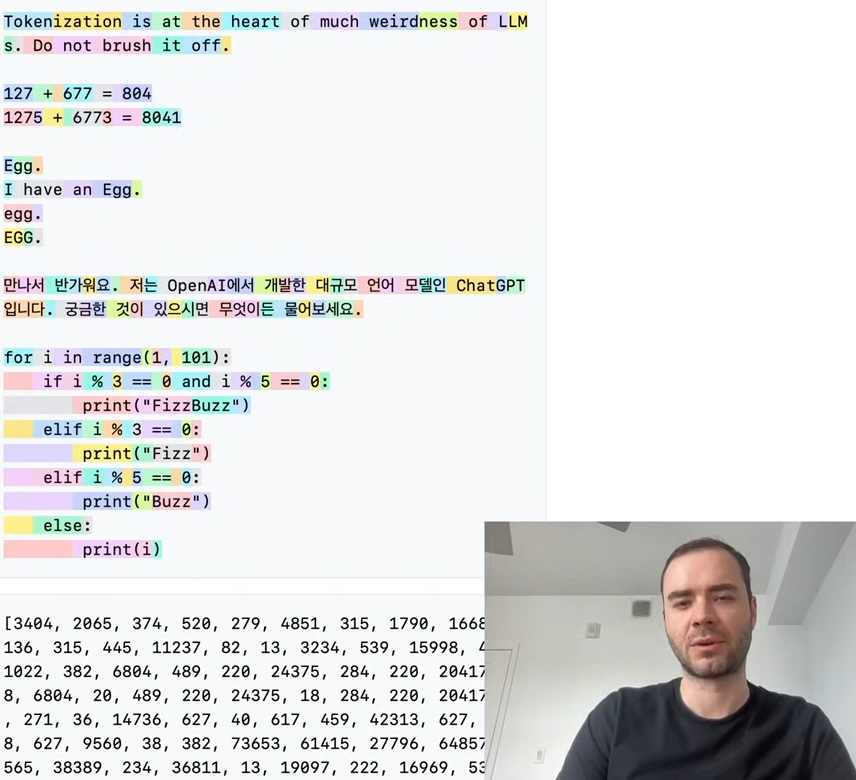

Questions as mentioned by Andrej, -1:51:31-2:10:20

_Italized = editor note_
> Tokenization is at the heart of much weirdness of LLMs. Do not brush it off.  
- Why can't LLM spell words? **Tokenization**.
- Why can't LLM do super simple string processing tasks like reversing a string? **Tokenization**.
 - _It can hardly see the tokens as chars unless specified to chunk it out one by one._
 - _E.g. `hello world`, it may see as ` h`, `el`, `lo `, ` w`, `or`, `ld`. instead of `h`,`e`,`l`,`l`,`o`,` `,`w`,`o`,`r`,`l`,`d` which is much easier to reverse._
- Why is LLM worse at non-English languages (e.g. Japanese)? **Tokenization**.
 - _It is not trained as sophisticated in non-English language._
- Why is LLM bad at simple arithmetic? **Tokenization**.
 - _The way it tokenize numbers._
- Why did GPT-2 have more than necessary trouble coding in Python? **partly Tokenization**.
 - _Modeling issue, and encoding technique (tokenization) matters._
- Why did my LLM abruptly halt when it sees the string "<|endoftext|>"? **Tokenization**.
 - _It doesn't parse the <|endoftext|>._
- What is this weird warning I get about a "trailing whitespace"? **Tokenization**.
 - _At base model (without assistant prompt, a text completion model)._
 - _E.g. Here is a tag line for an ice cream shop:_
 - _vs.  Here is a tag line for an ice cream shop: _
 - _That space token at the end is supposed to be for the next token by generation. We have begun the token already, the next token is now split up, out of distribution, and arbitrarily something bad/unexpected will happen._
 - _Something funny happens when you prompt `.DefaultCellSty` (not 1 token), instead of `.DefaultCellStyle` (1 token)._
  - _It's giving the model brain damage._
 - _What you would like out of a completion model API, is something like putting it in default cell stat, if we ask for the next token sequence,_
 - _instead of appending, the model will consider a lot more tokens, where it search over the characters, etc._
 - _This is called `unstable token`. A whole new topic can be discovered here._
- Why the LLM break if I ask it about "SolidGoldMagikarp"? **Tokenization**.
 - [blog](https://www.lesswrong.com/posts/aPeJE8bSo6rAFoLqg/solidgoldmagikarp-plus-prompt-generation)
 - _So this person went to `embedding cluster stable`, and clustered the tokens based on their embedding representations._
 - _They noticed a cluster of tokens that look strange, including `SolidGoldMagikarp`._
 - _These tokens makes no sense, and there are a bunch of them. Asking the model about these tokens will completely break the model. At least for GPT3 era models. Which this issue is now fixed in later models._
 - What happens is that perhaps tokenization model's training dataset had some Reddit datasets (SolidGoldMagikarp was a Reddit user) and they are mentioned a lot in replies.
 - But during training the actual model, the training set do not have the same tokenization's dataset. That token never occurs in LM.
 - This token never get updated in embedding table, it is left untrained (kinda like unallocated memory in binary program written in C).
 - This creates undefined behaviour.
- Why should I prefer to use YAML over JSON with LLMs? **Tokenization**.
 - _JSON is dense in tokens and YAML is not as dense._
 - _Token economy in paying context length, processing structured data, find structures with less token density for a more efficient encoding scheme._
- Why is LLM not actually end-to-end language modeling? **Tokenization**.
- What is the real root of suffering? **Tokenization**.😂

# Main Code - Dive into GPT Tokenizer

In [ ]:
string_example = "안녕하세요 👋 (hello in Korean!)"

## Unicode Byte Encodings, ASCII, UTF-8, 16, 32

### Q: What are the texts in python?

A: [Text sequence type](https://docs.python.org/3/library/stdtypes.html)
- Strings are immutable sequences of **[Unicode](https://en.wikipedia.org/wiki/Unicode) code points**.

To access Unicode code point given a Single Character, use `ord()` in python.

In [ ]:
ord('j'), ord('👋'), ord(' ')

(106, 128075, 32)

In [ ]:
[ord(x) for x in "안녕하세요 👋 (hello in Korean!)"]

[50504,
 45397,
 54616,
 49464,
 50836,
 32,
 128075,
 32,
 40,
 104,
 101,
 108,
 108,
 111,
 32,
 105,
 110,
 32,
 75,
 111,
 114,
 101,
 97,
 110,
 33,
 41]

### Q: Why UTF-8?

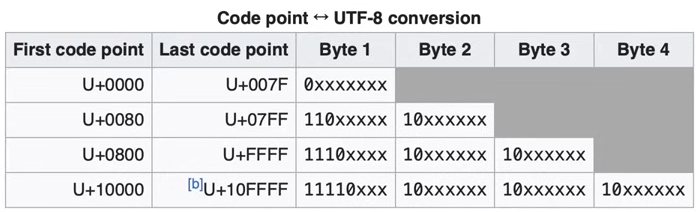

- Takes every single coded point, translate by stream, this stream is between 1-4 Bytes.
- Major advantage is UTF-8 is the only one that is **backwards compatible** and is **much simpler ASCII encoding.

- UTF-32 is fixed instead of variable length but has many other downsides (just web-browse it)

- [Nathan Reed's Unicode blog](https://www.reedbeta.com/blog/programmers-intro-to-unicode/)
- [UTF-8 everywhere](https://utf8everywhere.org/)

### Codes

### UTF-8, UTF-16, UTF-32

In [ ]:
string_example.encode("utf-8"), list(string_example.encode("utf-8"))

(b'\xec\x95\x88\xeb\x85\x95\xed\x95\x98\xec\x84\xb8\xec\x9a\x94 \xf0\x9f\x91\x8b (hello in Korean!)',
 [236,
  149,
  136,
  235,
  133,
  149,
  237,
  149,
  152,
  236,
  132,
  184,
  236,
  154,
  148,
  32,
  240,
  159,
  145,
  139,
  32,
  40,
  104,
  101,
  108,
  108,
  111,
  32,
  105,
  110,
  32,
  75,
  111,
  114,
  101,
  97,
  110,
  33,
  41])

In [ ]:
string_example.encode("utf-8"), list(string_example.encode("utf-16"))

(b'\xec\x95\x88\xeb\x85\x95\xed\x95\x98\xec\x84\xb8\xec\x9a\x94 \xf0\x9f\x91\x8b (hello in Korean!)',
 [255,
  254,
  72,
  197,
  85,
  177,
  88,
  213,
  56,
  193,
  148,
  198,
  32,
  0,
  61,
  216,
  75,
  220,
  32,
  0,
  40,
  0,
  104,
  0,
  101,
  0,
  108,
  0,
  108,
  0,
  111,
  0,
  32,
  0,
  105,
  0,
  110,
  0,
  32,
  0,
  75,
  0,
  111,
  0,
  114,
  0,
  101,
  0,
  97,
  0,
  110,
  0,
  33,
  0,
  41,
  0])

**Note 1**: You can see a lot of "0" followed by something. Same thing with UTF-16
- What this is going to do is the text will be stretch out to very long sequences of bytes.
 - Embedding table will be small,
 - Prediction at final top layer will be small,
 - But sequences are very long.
- We also have finite context length, very long sequences have inefficiency,
 - that does not allow us to have long context length if we have long sequences.
 - _Ed note: Basically you either trade long context length or long bytes per token (sequence) because of computational limitation._


**Note 2**: UTF-8 has 256 possible tokens. This is a small vocabulary size.
- This allows support of larger vocabulary size
 - that we can tune as hyperparameters
 - We can turn to _**Byte-pair encoding algorithm**_ to compress these Byte sequences to a variable amount.


## Deleting Tokenization

[Paper](https://arxiv.org/abs/2305.07185)

There is a whole paper that proposed a hierarchichal structure that feeds raw bite sequence into the language model (skip tokenization), but
- Need to change the architecture of the transformer.
- Becomes extremely expensive because of the long sequences.
- Has not been proven yet to a sufficient scale to do this.

## Byte Pair Encoding (BPE) Algorithm

[wiki](https://en.wikipedia.org/wiki/Byte-pair_encoding#Example)

The example explains the concept well.

Result: aaabdaaabac -> XdXac
Only has 5 tokens with vocab length of 7 instead of 11 tokens with vocab length of 4, in a sequence. Compressed.

### Code - Short Example

In [ ]:
# Text from https://www.reedbeta.com/blog/programmers-intro-to-unicode/
text = "Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception."
tokens = text.encode("utf-8") # Raw bytes
tokens = list(map(int, tokens)) # Convert to a list of integers in range 0..255 for convenience
print('---')
print(text)
print("Word Length:", len(text))
print('---')
print(tokens)
print("Token Length:", len(tokens))

---
Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.
Word Length: 533
---
[239, 188, 181, 239, 189, 142, 239, 189, 137, 239, 189, 131, 239, 189, 143, 239, 189, 132, 239, 189, 133, 33, 32, 240, 159, 133, 164, 240, 159, 133, 157, 240, 159, 133, 152, 240, 159, 133, 146, 240, 159, 133, 158, 240, 159, 133, 147, 240, 159, 133, 148, 226, 128, 189, 32, 240, 159, 135, 186, 226, 128, 140, 240, 159, 135, 179, 226, 128, 140, 240, 159, 135, 174, 226, 128, 140, 240, 159, 135, 168, 226, 128, 140, 240, 159, 135, 180, 226, 128

Why Word Length < Token Length?
- Complex characters (e.g. 🅤🅝🅘🅒🅞🅓🅔) Becomes more than just 1 token because of its uniqueness.

### Get stats

In [ ]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]): # Pythonic way to iterate consecutive elements
        counts[pair] = counts.get(pair, 0) + 1
    return counts

stats = get_stats(tokens)
print(stats)
print(sorted(((v,k) for k,v in stats.items()), reverse=True))

{(239, 188): 1, (188, 181): 1, (181, 239): 1, (239, 189): 6, (189, 142): 1, (142, 239): 1, (189, 137): 1, (137, 239): 1, (189, 131): 1, (131, 239): 1, (189, 143): 1, (143, 239): 1, (189, 132): 1, (132, 239): 1, (189, 133): 1, (133, 33): 1, (33, 32): 2, (32, 240): 3, (240, 159): 15, (159, 133): 7, (133, 164): 1, (164, 240): 1, (133, 157): 1, (157, 240): 1, (133, 152): 1, (152, 240): 1, (133, 146): 1, (146, 240): 1, (133, 158): 1, (158, 240): 1, (133, 147): 1, (147, 240): 1, (133, 148): 1, (148, 226): 1, (226, 128): 12, (128, 189): 1, (189, 32): 1, (159, 135): 7, (135, 186): 1, (186, 226): 1, (128, 140): 6, (140, 240): 6, (135, 179): 1, (179, 226): 1, (135, 174): 1, (174, 226): 1, (135, 168): 1, (168, 226): 1, (135, 180): 1, (180, 226): 1, (135, 169): 1, (169, 226): 1, (135, 170): 1, (170, 33): 1, (159, 152): 1, (152, 132): 1, (132, 32): 1, (32, 84): 1, (84, 104): 1, (104, 101): 6, (101, 32): 20, (32, 118): 1, (118, 101): 3, (101, 114): 6, (114, 121): 2, (121, 32): 2, (32, 110): 2, (110,

Highest occurance: 'e' and ' ' (space)

In [ ]:
top_pair = max(stats, key=stats.get)
top_pair, chr(101), chr(32)

((101, 32), 'e', ' ')

### Merge the most common pair

In [ ]:
def merge(ids, pair, idx):
  # In the list of ints (ids), replace all consecutive occurences of pair with the new token idx
  newids = []
  i = 0
  while i < len(ids):
    # !! If we are not at the very last position AND the pair matches,
    # Replace it
    if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
      newids.append(idx)
      i += 2
    else:
      newids.append(ids[i])
      i += 1
  return newids

print(merge([5, 6, 6, 7, 9, 1], (6, 7), 99))

tokens2 = merge(tokens, top_pair, 256)
print(tokens2)
print("New Token Length:", len(tokens2))

[5, 6, 99, 9, 1]
[239, 188, 181, 239, 189, 142, 239, 189, 137, 239, 189, 131, 239, 189, 143, 239, 189, 132, 239, 189, 133, 33, 32, 240, 159, 133, 164, 240, 159, 133, 157, 240, 159, 133, 152, 240, 159, 133, 146, 240, 159, 133, 158, 240, 159, 133, 147, 240, 159, 133, 148, 226, 128, 189, 32, 240, 159, 135, 186, 226, 128, 140, 240, 159, 135, 179, 226, 128, 140, 240, 159, 135, 174, 226, 128, 140, 240, 159, 135, 168, 226, 128, 140, 240, 159, 135, 180, 226, 128, 140, 240, 159, 135, 169, 226, 128, 140, 240, 159, 135, 170, 33, 32, 240, 159, 152, 132, 32, 84, 104, 256, 118, 101, 114, 121, 32, 110, 97, 109, 256, 115, 116, 114, 105, 107, 101, 115, 32, 102, 101, 97, 114, 32, 97, 110, 100, 32, 97, 119, 256, 105, 110, 116, 111, 32, 116, 104, 256, 104, 101, 97, 114, 116, 115, 32, 111, 102, 32, 112, 114, 111, 103, 114, 97, 109, 109, 101, 114, 115, 32, 119, 111, 114, 108, 100, 119, 105, 100, 101, 46, 32, 87, 256, 97, 108, 108, 32, 107, 110, 111, 119, 32, 119, 256, 111, 117, 103, 104, 116, 32, 116, 111, 

### Code - Long Example

### Shorten

In [ ]:
# Making the training text longer to have more representative token statistics
# Text from https://www.reedbeta.com/blog/programmers-intro-to-unicode/
text = """A Programmer’s Introduction to Unicode March 3, 2017 · Coding · 22 Comments  Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺\u200c🇳\u200c🇮\u200c🇨\u200c🇴\u200c🇩\u200c🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.  A few months ago, I got interested in Unicode and decided to spend some time learning more about it in detail. In this article, I’ll give an introduction to it from a programmer’s point of view.  I’m going to focus on the character set and what’s involved in working with strings and files of Unicode text. However, in this article I’m not going to talk about fonts, text layout/shaping/rendering, or localization in detail—those are separate issues, beyond my scope (and knowledge) here.  Diversity and Inherent Complexity The Unicode Codespace Codespace Allocation Scripts Usage Frequency Encodings UTF-8 UTF-16 Combining Marks Canonical Equivalence Normalization Forms Grapheme Clusters And More… Diversity and Inherent Complexity As soon as you start to study Unicode, it becomes clear that it represents a large jump in complexity over character sets like ASCII that you may be more familiar with. It’s not just that Unicode contains a much larger number of characters, although that’s part of it. Unicode also has a great deal of internal structure, features, and special cases, making it much more than what one might expect a mere “character set” to be. We’ll see some of that later in this article.  When confronting all this complexity, especially as an engineer, it’s hard not to find oneself asking, “Why do we need all this? Is this really necessary? Couldn’t it be simplified?”  However, Unicode aims to faithfully represent the entire world’s writing systems. The Unicode Consortium’s stated goal is “enabling people around the world to use computers in any language”. And as you might imagine, the diversity of written languages is immense! To date, Unicode supports 135 different scripts, covering some 1100 languages, and there’s still a long tail of over 100 unsupported scripts, both modern and historical, which people are still working to add.  Given this enormous diversity, it’s inevitable that representing it is a complicated project. Unicode embraces that diversity, and accepts the complexity inherent in its mission to include all human writing systems. It doesn’t make a lot of trade-offs in the name of simplification, and it makes exceptions to its own rules where necessary to further its mission.  Moreover, Unicode is committed not just to supporting texts in any single language, but also to letting multiple languages coexist within one text—which introduces even more complexity.  Most programming languages have libraries available to handle the gory low-level details of text manipulation, but as a programmer, you’ll still need to know about certain Unicode features in order to know when and how to apply them. It may take some time to wrap your head around it all, but don’t be discouraged—think about the billions of people for whom your software will be more accessible through supporting text in their language. Embrace the complexity!  The Unicode Codespace Let’s start with some general orientation. The basic elements of Unicode—its “characters”, although that term isn’t quite right—are called code points. Code points are identified by number, customarily written in hexadecimal with the prefix “U+”, such as U+0041 “A” latin capital letter a or U+03B8 “θ” greek small letter theta. Each code point also has a short name, and quite a few other properties, specified in the Unicode Character Database.  The set of all possible code points is called the codespace. The Unicode codespace consists of 1,114,112 code points. However, only 128,237 of them—about 12% of the codespace—are actually assigned, to date. There’s plenty of room for growth! Unicode also reserves an additional 137,468 code points as “private use” areas, which have no standardized meaning and are available for individual applications to define for their own purposes.  Codespace Allocation To get a feel for how the codespace is laid out, it’s helpful to visualize it. Below is a map of the entire codespace, with one pixel per code point. It’s arranged in tiles for visual coherence; each small square is 16×16 = 256 code points, and each large square is a “plane” of 65,536 code points. There are 17 planes altogether.  Map of the Unicode codespace (click to zoom)  White represents unassigned space. Blue is assigned code points, green is private-use areas, and the small red area is surrogates (more about those later). As you can see, the assigned code points are distributed somewhat sparsely, but concentrated in the first three planes.  Plane 0 is also known as the “Basic Multilingual Plane”, or BMP. The BMP contains essentially all the characters needed for modern text in any script, including Latin, Cyrillic, Greek, Han (Chinese), Japanese, Korean, Arabic, Hebrew, Devanagari (Indian), and many more.  (In the past, the codespace was just the BMP and no more—Unicode was originally conceived as a straightforward 16-bit encoding, with only 65,536 code points. It was expanded to its current size in 1996. However, the vast majority of code points in modern text belong to the BMP.)  Plane 1 contains historical scripts, such as Sumerian cuneiform and Egyptian hieroglyphs, as well as emoji and various other symbols. Plane 2 contains a large block of less-common and historical Han characters. The remaining planes are empty, except for a small number of rarely-used formatting characters in Plane 14; planes 15–16 are reserved entirely for private use.  Scripts Let’s zoom in on the first three planes, since that’s where the action is:  Map of scripts in Unicode planes 0–2 (click to zoom)  This map color-codes the 135 different scripts in Unicode. You can see how Han () and Korean () take up most of the range of the BMP (the left large square). By contrast, all of the European, Middle Eastern, and South Asian scripts fit into the first row of the BMP in this diagram.  Many areas of the codespace are adapted or copied from earlier encodings. For example, the first 128 code points of Unicode are just a copy of ASCII. This has clear benefits for compatibility—it’s easy to losslessly convert texts from smaller encodings into Unicode (and the other direction too, as long as no characters outside the smaller encoding are used).  Usage Frequency One more interesting way to visualize the codespace is to look at the distribution of usage—in other words, how often each code point is actually used in real-world texts. Below is a heat map of planes 0–2 based on a large sample of text from Wikipedia and Twitter (all languages). Frequency increases from black (never seen) through red and yellow to white.  Heat map of code point usage frequency in Unicode planes 0–2 (click to zoom)  You can see that the vast majority of this text sample lies in the BMP, with only scattered usage of code points from planes 1–2. The biggest exception is emoji, which show up here as the several bright squares in the bottom row of plane 1.  Encodings We’ve seen that Unicode code points are abstractly identified by their index in the codespace, ranging from U+0000 to U+10FFFF. But how do code points get represented as bytes, in memory or in a file?  The most convenient, computer-friendliest (and programmer-friendliest) thing to do would be to just store the code point index as a 32-bit integer. This works, but it consumes 4 bytes per code point, which is sort of a lot. Using 32-bit ints for Unicode will cost you a bunch of extra storage, memory, and performance in bandwidth-bound scenarios, if you work with a lot of text.  Consequently, there are several more-compact encodings for Unicode. The 32-bit integer encoding is officially called UTF-32 (UTF = “Unicode Transformation Format”), but it’s rarely used for storage. At most, it comes up sometimes as a temporary internal representation, for examining or operating on the code points in a string.  Much more commonly, you’ll see Unicode text encoded as either UTF-8 or UTF-16. These are both variable-length encodings, made up of 8-bit or 16-bit units, respectively. In these schemes, code points with smaller index values take up fewer bytes, which saves a lot of memory for typical texts. The trade-off is that processing UTF-8/16 texts is more programmatically involved, and likely slower.  UTF-8 In UTF-8, each code point is stored using 1 to 4 bytes, based on its index value.  UTF-8 uses a system of binary prefixes, in which the high bits of each byte mark whether it’s a single byte, the beginning of a multi-byte sequence, or a continuation byte; the remaining bits, concatenated, give the code point index. This table shows how it works:  UTF-8 (binary)\tCode point (binary)\tRange 0xxxxxxx\txxxxxxx\tU+0000–U+007F 110xxxxx 10yyyyyy\txxxxxyyyyyy\tU+0080–U+07FF 1110xxxx 10yyyyyy 10zzzzzz\txxxxyyyyyyzzzzzz\tU+0800–U+FFFF 11110xxx 10yyyyyy 10zzzzzz 10wwwwww\txxxyyyyyyzzzzzzwwwwww\tU+10000–U+10FFFF A handy property of UTF-8 is that code points below 128 (ASCII characters) are encoded as single bytes, and all non-ASCII code points are encoded using sequences of bytes 128–255. This has a couple of nice consequences. First, any strings or files out there that are already in ASCII can also be interpreted as UTF-8 without any conversion. Second, lots of widely-used string programming idioms—such as null termination, or delimiters (newlines, tabs, commas, slashes, etc.)—will just work on UTF-8 strings. ASCII bytes never occur inside the encoding of non-ASCII code points, so searching byte-wise for a null terminator or a delimiter will do the right thing.  Thanks to this convenience, it’s relatively simple to extend legacy ASCII programs and APIs to handle UTF-8 strings. UTF-8 is very widely used in the Unix/Linux and Web worlds, and many programmers argue UTF-8 should be the default encoding everywhere.  However, UTF-8 isn’t a drop-in replacement for ASCII strings in all respects. For instance, code that iterates over the “characters” in a string will need to decode UTF-8 and iterate over code points (or maybe grapheme clusters—more about those later), not bytes. When you measure the “length” of a string, you’ll need to think about whether you want the length in bytes, the length in code points, the width of the text when rendered, or something else.  UTF-16 The other encoding that you’re likely to encounter is UTF-16. It uses 16-bit words, with each code point stored as either 1 or 2 words.  Like UTF-8, we can express the UTF-16 encoding rules in the form of binary prefixes:  UTF-16 (binary)\tCode point (binary)\tRange xxxxxxxxxxxxxxxx\txxxxxxxxxxxxxxxx\tU+0000–U+FFFF 110110xxxxxxxxxx 110111yyyyyyyyyy\txxxxxxxxxxyyyyyyyyyy + 0x10000\tU+10000–U+10FFFF A more common way that people talk about UTF-16 encoding, though, is in terms of code points called “surrogates”. All the code points in the range U+D800–U+DFFF—or in other words, the code points that match the binary prefixes 110110 and 110111 in the table above—are reserved specifically for UTF-16 encoding, and don’t represent any valid characters on their own. They’re only meant to occur in the 2-word encoding pattern above, which is called a “surrogate pair”. Surrogate code points are illegal in any other context! They’re not allowed in UTF-8 or UTF-32 at all.  Historically, UTF-16 is a descendant of the original, pre-1996 versions of Unicode, in which there were only 65,536 code points. The original intention was that there would be no different “encodings”; Unicode was supposed to be a straightforward 16-bit character set. Later, the codespace was expanded to make room for a long tail of less-common (but still important) Han characters, which the Unicode designers didn’t originally plan for. Surrogates were then introduced, as—to put it bluntly—a kludge, allowing 16-bit encodings to access the new code points.  Today, Javascript uses UTF-16 as its standard string representation: if you ask for the length of a string, or iterate over it, etc., the result will be in UTF-16 words, with any code points outside the BMP expressed as surrogate pairs. UTF-16 is also used by the Microsoft Win32 APIs; though Win32 supports either 8-bit or 16-bit strings, the 8-bit version unaccountably still doesn’t support UTF-8—only legacy code-page encodings, like ANSI. This leaves UTF-16 as the only way to get proper Unicode support in Windows. (Update: in Win10 version 1903, they finally added UTF-8 support to the 8-bit APIs! 😊)  By the way, UTF-16’s words can be stored either little-endian or big-endian. Unicode has no opinion on that issue, though it does encourage the convention of putting U+FEFF zero width no-break space at the top of a UTF-16 file as a byte-order mark, to disambiguate the endianness. (If the file doesn’t match the system’s endianness, the BOM will be decoded as U+FFFE, which isn’t a valid code point.)  Combining Marks In the story so far, we’ve been focusing on code points. But in Unicode, a “character” can be more complicated than just an individual code point!  Unicode includes a system for dynamically composing characters, by combining multiple code points together. This is used in various ways to gain flexibility without causing a huge combinatorial explosion in the number of code points.  In European languages, for example, this shows up in the application of diacritics to letters. Unicode supports a wide range of diacritics, including acute and grave accents, umlauts, cedillas, and many more. All these diacritics can be applied to any letter of any alphabet—and in fact, multiple diacritics can be used on a single letter.  If Unicode tried to assign a distinct code point to every possible combination of letter and diacritics, things would rapidly get out of hand. Instead, the dynamic composition system enables you to construct the character you want, by starting with a base code point (the letter) and appending additional code points, called “combining marks”, to specify the diacritics. When a text renderer sees a sequence like this in a string, it automatically stacks the diacritics over or under the base letter to create a composed character.  For example, the accented character “Á” can be expressed as a string of two code points: U+0041 “A” latin capital letter a plus U+0301 “◌́” combining acute accent. This string automatically gets rendered as a single character: “Á”.  Now, Unicode does also include many “precomposed” code points, each representing a letter with some combination of diacritics already applied, such as U+00C1 “Á” latin capital letter a with acute or U+1EC7 “ệ” latin small letter e with circumflex and dot below. I suspect these are mostly inherited from older encodings that were assimilated into Unicode, and kept around for compatibility. In practice, there are precomposed code points for most of the common letter-with-diacritic combinations in European-script languages, so they don’t use dynamic composition that much in typical text.  Still, the system of combining marks does allow for an arbitrary number of diacritics to be stacked on any base character. The reductio-ad-absurdum of this is Zalgo text, which works by ͖͟ͅr͞aṋ̫̠̖͈̗d͖̻̹óm̪͙͕̗̝ļ͇̰͓̳̫ý͓̥̟͍ ̕s̫t̫̱͕̗̰̼̘͜a̼̩͖͇̠͈̣͝c̙͍k̖̱̹͍͘i̢n̨̺̝͇͇̟͙ģ̫̮͎̻̟ͅ ̕n̼̺͈͞u̮͙m̺̭̟̗͞e̞͓̰̤͓̫r̵o̖ṷs҉̪͍̭̬̝̤ ̮͉̝̞̗̟͠d̴̟̜̱͕͚i͇̫̼̯̭̜͡ḁ͙̻̼c̲̲̹r̨̠̹̣̰̦i̱t̤̻̤͍͙̘̕i̵̜̭̤̱͎c̵s ͘o̱̲͈̙͖͇̲͢n͘ ̜͈e̬̲̠̩ac͕̺̠͉h̷̪ ̺̣͖̱ḻ̫̬̝̹ḙ̙̺͙̭͓̲t̞̞͇̲͉͍t̷͔̪͉̲̻̠͙e̦̻͈͉͇r͇̭̭̬͖,̖́ ̜͙͓̣̭s̘̘͈o̱̰̤̲ͅ ̛̬̜̙t̼̦͕̱̹͕̥h̳̲͈͝ͅa̦t̻̲ ̻̟̭̦̖t̛̰̩h̠͕̳̝̫͕e͈̤̘͖̞͘y҉̝͙ ̷͉͔̰̠o̞̰v͈͈̳̘͜er̶f̰͈͔ḻ͕̘̫̺̲o̲̭͙͠ͅw̱̳̺ ͜t̸h͇̭͕̳͍e̖̯̟̠ ͍̞̜͔̩̪͜ļ͎̪̲͚i̝̲̹̙̩̹n̨̦̩̖ḙ̼̲̼͢ͅ ̬͝s̼͚̘̞͝p͙̘̻a̙c҉͉̜̤͈̯̖i̥͡n̦̠̱͟g̸̗̻̦̭̮̟ͅ ̳̪̠͖̳̯̕a̫͜n͝d͡ ̣̦̙ͅc̪̗r̴͙̮̦̹̳e͇͚̞͔̹̫͟a̙̺̙ț͔͎̘̹ͅe̥̩͍ a͖̪̜̮͙̹n̢͉̝ ͇͉͓̦̼́a̳͖̪̤̱p̖͔͔̟͇͎͠p̱͍̺ę̲͎͈̰̲̤̫a̯͜r̨̮̫̣̘a̩̯͖n̹̦̰͎̣̞̞c̨̦̱͔͎͍͖e̬͓͘ ̤̰̩͙̤̬͙o̵̼̻̬̻͇̮̪f̴ ̡̙̭͓͖̪̤“̸͙̠̼c̳̗͜o͏̼͙͔̮r̞̫̺̞̥̬ru̺̻̯͉̭̻̯p̰̥͓̣̫̙̤͢t̳͍̳̖ͅi̶͈̝͙̼̙̹o̡͔n̙̺̹̖̩͝ͅ”̨̗͖͚̩.̯͓  A few other places where dynamic character composition shows up in Unicode:  Vowel-pointing notation in Arabic and Hebrew. In these languages, words are normally spelled with some of their vowels left out. They then have diacritic notation to indicate the vowels (used in dictionaries, language-teaching materials, children’s books, and such). These diacritics are expressed with combining marks.  A Hebrew example, with niqqud:\tאֶת דַלְתִּי הֵזִיז הֵנִיעַ, קֶטֶב לִשְׁכַּתִּי יָשׁוֹד Normal writing (no niqqud):\tאת דלתי הזיז הניע, קטב לשכתי ישוד Devanagari, the script used to write Hindi, Sanskrit, and many other South Asian languages, expresses certain vowels as combining marks attached to consonant letters. For example, “ह” + “\u200bि” = “हि” (“h” + “i” = “hi”). Korean characters stand for syllables, but they are composed of letters called jamo that stand for the vowels and consonants in the syllable. While there are code points for precomposed Korean syllables, it’s also possible to dynamically compose them by concatenating their jamo. For example, “ᄒ” + “ᅡ” + “ᆫ” = “한” (“h” + “a” + “n” = “han”). Canonical Equivalence In Unicode, precomposed characters exist alongside the dynamic composition system. A consequence of this is that there are multiple ways to express “the same” string—different sequences of code points that result in the same user-perceived characters. For example, as we saw earlier, we can express the character “Á” either as the single code point U+00C1, or as the string of two code points U+0041 U+0301.  Another source of ambiguity is the ordering of multiple diacritics in a single character. Diacritic order matters visually when two diacritics apply to the same side of the base character, e.g. both above: “ǡ” (dot, then macron) is different from “ā̇” (macron, then dot). However, when diacritics apply to different sides of the character, e.g. one above and one below, then the order doesn’t affect rendering. Moreover, a character with multiple diacritics might have one of the diacritics precomposed and others expressed as combining marks.  For example, the Vietnamese letter “ệ” can be expressed in five different ways:  Fully precomposed: U+1EC7 “ệ” Partially precomposed: U+1EB9 “ẹ” + U+0302 “◌̂” Partially precomposed: U+00EA “ê” + U+0323 “◌̣” Fully decomposed: U+0065 “e” + U+0323 “◌̣” + U+0302 “◌̂” Fully decomposed: U+0065 “e” + U+0302 “◌̂” + U+0323 “◌̣” Unicode refers to set of strings like this as “canonically equivalent”. Canonically equivalent strings are supposed to be treated as identical for purposes of searching, sorting, rendering, text selection, and so on. This has implications for how you implement operations on text. For example, if an app has a “find in file” operation and the user searches for “ệ”, it should, by default, find occurrences of any of the five versions of “ệ” above!  Normalization Forms To address the problem of “how to handle canonically equivalent strings”, Unicode defines several normalization forms: ways of converting strings into a canonical form so that they can be compared code-point-by-code-point (or byte-by-byte).  The “NFD” normalization form fully decomposes every character down to its component base and combining marks, taking apart any precomposed code points in the string. It also sorts the combining marks in each character according to their rendered position, so e.g. diacritics that go below the character come before the ones that go above the character. (It doesn’t reorder diacritics in the same rendered position, since their order matters visually, as previously mentioned.)  The “NFC” form, conversely, puts things back together into precomposed code points as much as possible. If an unusual combination of diacritics is called for, there may not be any precomposed code point for it, in which case NFC still precomposes what it can and leaves any remaining combining marks in place (again ordered by rendered position, as in NFD).  There are also forms called NFKD and NFKC. The “K” here refers to compatibility decompositions, which cover characters that are “similar” in some sense but not visually identical. However, I’m not going to cover that here.  Grapheme Clusters As we’ve seen, Unicode contains various cases where a thing that a user thinks of as a single “character” might actually be made up of multiple code points under the hood. Unicode formalizes this using the notion of a grapheme cluster: a string of one or more code points that constitute a single “user-perceived character”.  UAX #29 defines the rules for what, precisely, qualifies as a grapheme cluster. It’s approximately “a base code point followed by any number of combining marks”, but the actual definition is a bit more complicated; it accounts for things like Korean jamo, and emoji ZWJ sequences.  The main thing grapheme clusters are used for is text editing: they’re often the most sensible unit for cursor placement and text selection boundaries. Using grapheme clusters for these purposes ensures that you can’t accidentally chop off some diacritics when you copy-and-paste text, that left/right arrow keys always move the cursor by one visible character, and so on.  Another place where grapheme clusters are useful is in enforcing a string length limit—say, on a database field. While the true, underlying limit might be something like the byte length of the string in UTF-8, you wouldn’t want to enforce that by just truncating bytes. At a minimum, you’d want to “round down” to the nearest code point boundary; but even better, round down to the nearest grapheme cluster boundary. Otherwise, you might be corrupting the last character by cutting off a diacritic, or interrupting a jamo sequence or ZWJ sequence.  And More… There’s much more that could be said about Unicode from a programmer’s perspective! I haven’t gotten into such fun topics as case mapping, collation, compatibility decompositions and confusables, Unicode-aware regexes, or bidirectional text. Nor have I said anything yet about implementation issues—how to efficiently store and look-up data about the sparsely-assigned code points, or how to optimize UTF-8 decoding, string comparison, or NFC normalization. Perhaps I’ll return to some of those things in future posts.  Unicode is a fascinating and complex system. It has a many-to-one mapping between bytes and code points, and on top of that a many-to-one (or, under some circumstances, many-to-many) mapping between code points and “characters”. It has oddball special cases in every corner. But no one ever claimed that representing all written languages was going to be easy, and it’s clear that we’re never going back to the bad old days of a patchwork of incompatible encodings.  Further reading:  The Unicode Standard UTF-8 Everywhere Manifesto Dark corners of Unicode by Eevee ICU (International Components for Unicode)—C/C++/Java libraries implementing many Unicode algorithms and related things Python 3 Unicode Howto Google Noto Fonts—set of fonts intended to cover all assigned code points"""

### Continue

In [ ]:
tokens = text.encode("utf-8") # Raw bytes
tokens = list(map(int, tokens)) # Convert to a list of integers in range 0..255 for convenience

In [ ]:
# To merge pairs of tokens based on their frequency
# until reaching the desired final vocabulary size.

In [ ]:
""" def get_stats(ids)
- Calculates the frequency of each consecutive pair of tokens.
@param
  ids - List of token IDs
@return
  counts - Dict where keys are token pairs and values are frequencies
"""
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts

""" def merge(ids, pair, idx)
- Merges two consecutive tokens in the given list ids
  based on a specified pair and index.
- Replaces each occurrence of the specified token pair
  with the new token ID (idx).
@param
  ids - List of token IDs
  pair - Tuple containing two tokens that need to be merged
  idx - New ID that will replace the merged pair of tokens
"""
def merge(ids, pair, idx):
  newids = []
  i = 0
  while i < len(ids):
    # Check if the current token at index i matches the first element of the pair (pair[0])
    # and the next token (at index i+1) matches the second element of the pair (pair[1]).
    # Basically, find the token pair of interest.
    if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
      # Found the consecutive pair of tokens that need to be merged.
      newids.append(idx)
      i += 2 # Skip 2 that was just merged
    else:
      # Append the non-merging ones.
      newids.append(ids[i])
      i += 1
  # Return new list of tokens with merged ones.
  return newids

# --- New
""" def main()
- Initialize vocab_size = 276, accounts for 20 merges.
- Calculates how many merges are needed
  - vocab_size - initial_no_of_token
- Make a copy of original list of token IDs
  - ids = list(tokens)
- Create empty dictionary [merges],
  keep track of which pairs where merged and their corresponding new token IDs.
"""
vocab_size = 276 # Desired final vocabulary size
# Exactly 20 merges
num_merges = vocab_size - 256
ids = list(tokens) # Copy so we don't destroy the original list

merges = {} # (int, int) -> int

""" Loop for merging
- Loop run for how many merges expected [num_merges]. Each iter:
  - Get frequency stats of consecutive pairs in current list
    stats = get_stats(ids)
  - Identify most frequent
    pair = max(stats, key=stats.get)
  - Assign new token ID [idx] for this merging pair
  - Modify list of IDs by merging the specified pair via merge function.
  - Update dictionary merges.
"""

for i in range(num_merges):
  stats = get_stats(ids) # Get list of elements (stats of tokens)
  pair = max(stats, key=stats.get) # Get the most occuring element
  idx = 256 + i
  print(f"merging {pair} into a new token {idx}")
  ids = merge(ids, pair, idx)
  merges[pair] = idx

merging (101, 32) into a new token 256
merging (105, 110) into a new token 257
merging (115, 32) into a new token 258
merging (116, 104) into a new token 259
merging (101, 114) into a new token 260
merging (99, 111) into a new token 261
merging (116, 32) into a new token 262
merging (226, 128) into a new token 263
merging (44, 32) into a new token 264
merging (97, 110) into a new token 265
merging (111, 114) into a new token 266
merging (100, 32) into a new token 267
merging (97, 114) into a new token 268
merging (101, 110) into a new token 269
merging (257, 103) into a new token 270
merging (261, 100) into a new token 271
merging (121, 32) into a new token 272
merging (46, 32) into a new token 273
merging (97, 108) into a new token 274
merging (259, 256) into a new token 275


Note: New compressed token is eligible for further merges.

In [ ]:
print("tokens length:", len(tokens))
print("ids length:", len(ids))
print(f"compression ratio: {len(tokens) / len(ids):.2f}X")

tokens length: 24597
ids length: 19438
compression ratio: 1.27X


It's getting compressed!

## NOTE: Tokenizer is a seperate, pre-processing model

- Note by ANdrej: Tokenizer is a completely separate, independent module from the LLM. It has its own training dataset of text (which could be different from that of the LLM), on which you train the vocabulary using the Byte Pair Encoding (BPE) algorithm. It then translates back and forth between raw text and sequences of tokens. The LLM later only ever sees the tokens and never directly deals with any text.

Basically
- It is a raw text translator into a token sequence.
- It is independent from the actual LLM model.
- Training set of Tokenizer should be different to LLM's.

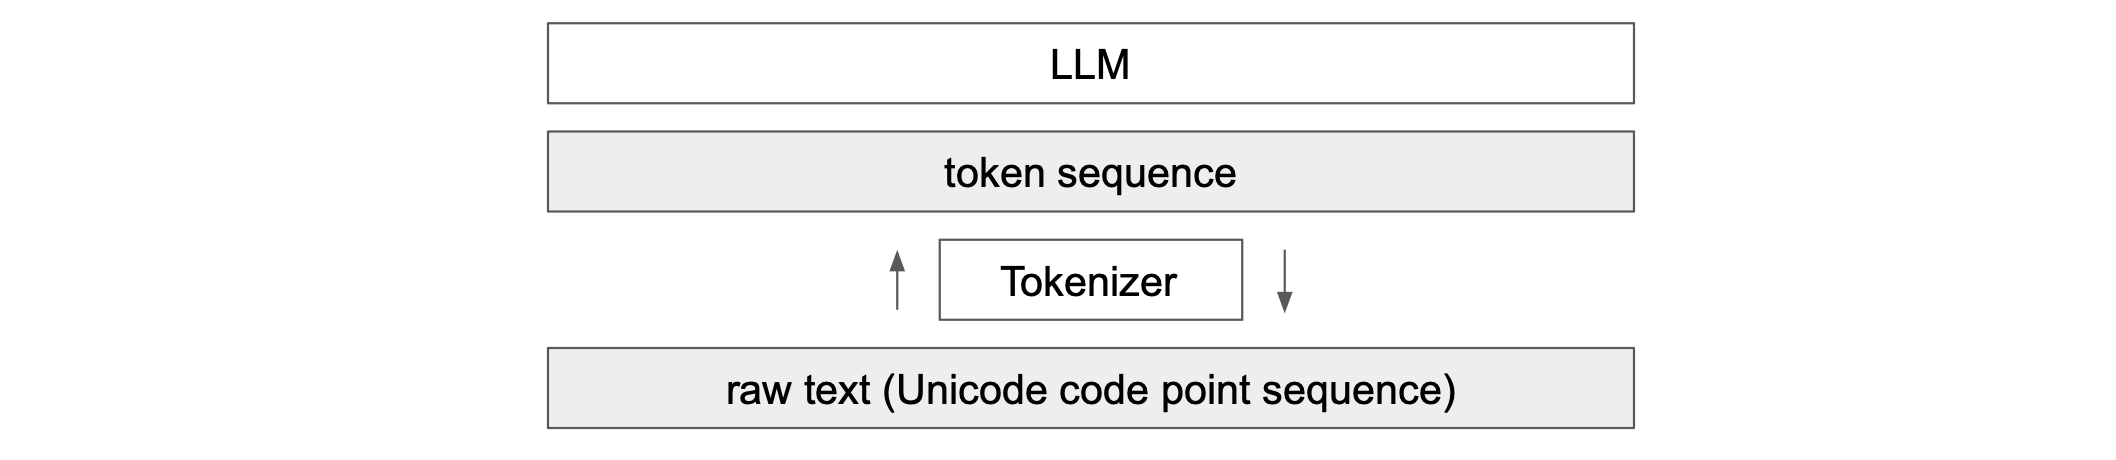

## Decoding and Encoding Tokenizer

### Decoder
Given a sequence of integers in the range [0, vocab_size], what is the text?


In [ ]:
# Important
#   tokens.decode("utf-8")
# This may cause error in the event that the decoder cannot find the Byte sequence
# Such as out of bound (Multi-byte)
# Not every Byte sequence is valid
# Use ', errors="replace"'

In [ ]:
vocab = {idx: bytes([idx]) for idx in range(256)}
for (p0, p1), idx in merges.items():
    vocab[idx] = vocab[p0] + vocab[p1]

def decode(ids):
  # given ids (list of integers), return Python string
  tokens = b"".join(vocab[idx] for idx in ids)
  text = tokens.decode("utf-8", errors="replace")
  return text

print(decode([128]))

�


### Encoder
Given a string, what are the tokens?

In [ ]:
merges

{(101, 32): 256,
 (105, 110): 257,
 (115, 32): 258,
 (116, 104): 259,
 (101, 114): 260,
 (99, 111): 261,
 (116, 32): 262,
 (226, 128): 263,
 (44, 32): 264,
 (97, 110): 265,
 (111, 114): 266,
 (100, 32): 267,
 (97, 114): 268,
 (101, 110): 269,
 (257, 103): 270,
 (261, 100): 271,
 (121, 32): 272,
 (46, 32): 273,
 (97, 108): 274,
 (259, 256): 275}

In [ ]:
def encode(text):
  # Given a string, return list of integers (the tokens)
  tokens = list(text.encode("utf-8"))
  # Continue as long as there are at least 2 tokens left to process.
  while len(tokens) >= 2:
    stats = get_stats(tokens)
    # min() to find pair of tokens that should be merged next.
    pair = min(stats, key=lambda p: merges.get(p, float("inf")))
    if pair not in merges:
      break # Nothing else can be merged
    idx = merges[pair]
    tokens = merge(tokens, pair, idx)
  return tokens

print(encode(""))

[]


In [ ]:
#   pair = min(stats, key=lambda p: merges.get(p, float("inf")))
# min on an iterator - Iterate over the key
# Key argument for min uses lambda function
#   that looks up each pair in the merges dictionary
#     returns its value if exists,
#   otherwise, defaults to infinity (float("inf")).
# This ensures that pair not found in merges are ignored
# when determining which pair to merge.

# Why float("inf")?
# Is a fallback. When consider a pair that does not occur in the merge,
# is not eligible to be merged.

In [ ]:
print(decode(encode("hello world")))

hello world


In [ ]:
text2 = decode(encode(text))
print(text2 == text)

True


In [ ]:
valtext = "Many common characters, including numerals, punctuation, and other symbols, are unified within the standard and are not treated as specific to any given writing system. Unicode encodes thousands of emoji, with the continued development thereof conducted by the Consortium as a part of the standard.[4] Moreover, the widespread adoption of Unicode was in large part responsible for the initial popularization of emoji outside of Japan. Unicode is ultimately capable of encoding more than 1.1 million characters."
valtext2 = decode(encode(valtext))
print(valtext2 == valtext)

True


## Forced splits using regex patterns (GPT series)

[Documentation of Regex Expression List](https://www.regular-expressions.info/unicode.html)

[More](https://docs.python.org/3/library/re.html)

"What part of the text will never be merged"

In [ ]:
# This breaks the sentence (list of texts) into multiple texts.
# Then, all the texts are processied independently by the tokenizer,
# and all of that result are simply concatenated.

# Basically, merges only happen between elements (words) and not across words
#   e.g. only merge in "Hello"  and not merge between "Hello world"

In [ ]:
# ?\p{N}+ = Any kind of numeric character in any script (Numbers)
#   Any number and characters are separated.
#   Any aprostrophe and characters are separated.

In [ ]:
import regex as re
gpt2pat = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")

print(re.findall(gpt2pat, "Hello've world123 how's are you!!!? D'Angelo"))

['Hello', "'ve", ' world', '123', ' how', "'s", ' are', ' you', '!!!?', ' D', "'", 'Angelo']


In [ ]:
# This is not perfect.
# If an apostrophe used is not in unicode, it does not get grouped together
# and becomes a separate group:
# E.g. "How's"->"How","'s", "D'Angelo"->"D","'","Angelo"

In [ ]:
# ?[^\s\p{L}\p{N}]+
# Not letters, not numbers: !!!?
# becomes a single group.

In [ ]:
# \s+
# Match white space
# (?!\S)
# Up to but not including the white space character.

# This is important.
# E.g.             word
# "           ", " word"
# Group the 'spaces' up to but not including the space next to word.

# The final \s+ just catches any final spaces.

- White space is not a letter, new attempt to match.

In [ ]:
example = """
for i in range(1, 101):
    if i % 3 == 0 and i % 5 == 0:
        print("FizzBuzz")
    elif i % 3 == 0:
        print("Fizz")
    elif i % 5 == 0:
        print("Buzz")
    else:
        print(i)
"""
print(re.findall(gpt2pat, example))

['\n', 'for', ' i', ' in', ' range', '(', '1', ',', ' 101', '):', '\n   ', ' if', ' i', ' %', ' 3', ' ==', ' 0', ' and', ' i', ' %', ' 5', ' ==', ' 0', ':', '\n       ', ' print', '("', 'FizzBuzz', '")', '\n   ', ' elif', ' i', ' %', ' 3', ' ==', ' 0', ':', '\n       ', ' print', '("', 'Fizz', '")', '\n   ', ' elif', ' i', ' %', ' 5', ' ==', ' 0', ':', '\n       ', ' print', '("', 'Buzz', '")', '\n   ', ' else', ':', '\n       ', ' print', '(', 'i', ')', '\n']


### Vibe check using tiktoken library

In [ ]:
!pip install tiktoken # added for colab

In [ ]:
import tiktoken

# GPT-2 (does not merge spaces)
enc = tiktoken.get_encoding("gpt2")
print(enc.encode("    hello world!!!"))

# GPT-4 (merges spaces)
enc = tiktoken.get_encoding("cl100k_base")
print(enc.encode("    hello world!!!"))

[220, 220, 220, 23748, 995, 10185]
[262, 24748, 1917, 12340]


In [ ]:
!wget https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/vocab.bpe
!wget https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/encoder.json

--2025-05-27 02:41:57--  https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/vocab.bpe
Resolving openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)... 57.150.97.129
Connecting to openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)|57.150.97.129|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 456318 (446K) [application/octet-stream]
Saving to: ‘vocab.bpe’

vocab.bpe           100%[===================>] 445.62K  2.06MB/s    in 0.2s    

2025-05-27 02:41:58 (2.06 MB/s) - ‘vocab.bpe’ saved [456318/456318]

--2025-05-27 02:41:58--  https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/encoder.json
Resolving openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)... 57.150.97.129
Connecting to openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)|57.150.97.129|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1042301 (1018K) [application/json]
Saving 

In [ ]:
import os, json

with open('encoder.json', 'r') as f:
    encoder = json.load(f) # <--- ~equivalent to our "vocab"

with open('vocab.bpe', 'r', encoding="utf-8") as f:
    bpe_data = f.read()
bpe_merges = [tuple(merge_str.split()) for merge_str in bpe_data.split('\n')[1:-1]]
# ^---- ~equivalent to our "merges"

Notice 'cl100k-base' which is used by gpt-4 does not concatenate the whole "       " as one group compared to gpt-2's tokenizer. Is useful for code tasks.

[Tiktoken library](https://github.com/openai/tiktoken/blob/main/tiktoken_ext/openai_public.py)

Read the "pat_str" part

### Differences between gpt-2 and cl100k (By GPT-4omini)


In [ ]:
# gpt-2
regex_1 = r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}++| ?\p{N}++| ?[^\s\p{L}\p{N}]++|\s++$|\s+(?!\S)|\s"""

# cl100k-base
regex_2 = r"""'(?i:[sdmt]|ll|ve|re)|[^\r\n\p{L}\p{N}]?+\p{L}++|\p{N}{1,3}+| ?[^\s\p{L}\p{N}]++[\r\n]*+|\s++$|\s*[\r\n]|\s+(?!\S)|\s"""

####  1. Apostrophe Contractions (e.g., 's, 'll)


In [ ]:
# regex_1 = '(?:[sdmt]|ll|ve|re)

- Matches contractions after apostrophes like `'s`, `'d`, `'m`, `'t`, `'ll`, `'ve`, `'re`
- Case-sensitive

In [ ]:
# regex_2 = '(?i:[sdmt]|ll|ve|re)

- Same as above but case-insensitive ((?i:...)).
- Will match `'S`, `'D`, etc., in uppercase.

Summary: `regex_1` is case-sensitive and `regex_2` is not.

#### 2. Letter Tokens (Unicode letters)

In [ ]:
# regex_1 =  ?\p{L}++

- Matches a space (optional) followed by 1 or more Unicode letters.

- Possessive quantifier (++) avoids backtracking.

In [ ]:
# regex_2 = [^\r\n\p{L}\p{N}]?+\p{L}++

- Matches an optional character that is not a newline, letter, or number, followed by letters.

- May match punctuation + letter as one token (e.g., .word)

 Summary: `regex_2` allows optional punctuation or non-letter prefix; `regex_1` does not.

#### 3. Numbers

In [ ]:
# regex_1 = ?\p{N}++

- Matches optional space + 1 or more digits (Unicode numbers)

In [ ]:
# regex_2 = \p{N}{1,3}+

- Matches 1 to 3 digits (grouped in small chunks)

SummaryL `regex_1` allows long numbers as a single token; `regex_2` breaks numbers into chunks of up to 3 digits (e.g., 12345 → 123, 45)

#### 4. Punctuation/Other Characters

In [ ]:
# regex_1 =  ?[^\s\p{L}\p{N}]++

- Matches optional space + one or more non-space, non-letter, non-number characters (punctuation etc.)

In [ ]:
# regex_2 = ?[^\s\p{L}\p{N}]++[\r\n]*+

- Matches same as above, plus **optional newlines** after the punctuation.

Summary: `regex_2` includes newline characters as part of punctuation tokens.

#### 5. Whitespace Handling

In [ ]:
# regex_1 = \s++$|\s+(?!\S)|\s

In [ ]:
# regex_2 = \s++$|\s*[\r\n]|\s+(?!\S)|\s

Difference:
- `regex_2` adds `\s*[\r\n]` - Matches any whitespace (0 or more) followed by newline; Matches specific `\r\n` patterns, separates them.
- `regex_1` doesn't account for specific newline handling; Treats newlines as regular whitespace.

### GPT-2's Tokenizer (Encoder.py)

[Source](https://github.com/openai/gpt-2/blob/master/src/encoder.py)

In [ ]:
import os, json

with open('encoder.json', 'r') as f:
    encoder = json.load(f) # <--- ~equivalent to our "vocab"

with open('vocab.bpe', 'r', encoding="utf-8") as f:
    bpe_data = f.read()
bpe_merges = [tuple(merge_str.split()) for merge_str in bpe_data.split('\n')[1:-1]]
# ^---- ~equivalent to our "merges"

## Special Tokens

In [ ]:
len(encoder) # 256 raw byte tokens. 50,000 merges. +1 special token

50257

In [ ]:
encoder['<|endoftext|>'] # The only special token in use for the GPT-2 base model

50256

- Used to delimit documents ments(?) in the training dataset.

> - "When creating the training data, we have all these documents, and we tokenize them and we get a stream of tokens,
- Those tokens only range from Z to 50256,
- Then in between those documents, we put **special end of text token**,
- We insert that token in between documents,
- as a signal to the LM that document has ended,
- and what follows is going to be unrelated to the document previously.

> - The LM has to learn from this token, it should wipe its 'memory' of what came before,
- and what came before this token is not infomative to what comes next,
- and we are giving limiter to these documents."

-Andrej


In [ ]:
""" Notes:
- End of text token, do not go through BPE merges,
- instead there is a code that actually outputs the tokens has
  special instructions for handling special tokens

- GPT2 encoder.py does not have this special token handling code.
- Instead, check Tiktoken Library (implemented in Rust)
"""

' Notes:\n- End of text token, do not go through BPE merges,\n- instead there is a code that actually outputs the tokens has\n  special instructions for handling special tokens\n\n- GPT2 encoder.py does not have this special token handling code.\n- Instead, check Tiktoken Library (implemented in Rust)\n'

[Tiktoken library with special token implementation](https://github.com/openai/tiktoken/blob/main/src/lib.rs)

- search "allowed_special", swapping out special tokens when found.

In [ ]:
""" Notes:
- This happens outside of BPE encoding.
- Special tokens are used not just in base LM (next token prediction),
  but also in fine-tuning stage.
- Because we don't want to delimit documents,
- we want to delimit entire conversations between ASSISTANT and USER.
"""

" Notes:\n- This happens outside of BPE encoding.\n- Special tokens are used not just in base LM (next token prediction),\n  but also in fine-tuning stage.\n- Because we don't want to delimit documents,\n- we want to delimit entire conversations between ASSISTANT and USER.\n"

Extra: cl100k-base
Special tokens:
- End of text
- FIM_Prefix (Fill in the middle)
- FIM_Middle
- FIM_Suffix
[Fill in middle paper](https://arxiv.org/abs/2207.14255)
- End of prompt

In [ ]:
""" Fine-tuning token making algorithm
- Note, changing BPE algorithm,
- the Transformer model and parameter need to be changed as well.
- Because this is adding integer, and you want to make sure that
- (E.g. Embedding Matrix) for vocabulary tokens has to be extended
  by adding a row.

  - Typically, this row is initialized with random numbers or equivalent
    because we need to have vector that stands in for that token.
  - You also need to go to the final layer of Transformer,
    make sure at projection is extended by 1.
"""

' Fine-tuning token making algorithm\n- Note, changing BPE algorithm,\n- the Transformer model and parameter need to be changed as well.\n- Because this is adding integer, and you want to make sure that\n- (E.g. Embedding Matrix) for vocabulary tokens has to be extended\n  by adding a row.\n\n  - Typically, this row is initialized with random numbers or equivalent\n    because we need to have vector that stands in for that token.\n  - You also need to go to the final layer of Transformer,\n    make sure at projection is extended by 1.\n'

## minBPE exercise

Code is part of [Andrej's minbpe repo](https://github.com/karpathy/minbpe) which is the solution to this exercise.

Follow [this](https://github.com/karpathy/minbpe/blob/master/exercise.md) as a step-by-step guide to fulfill the task.

Source:

In [ ]:
!wget https://github.com/karpathy/minbpe/blob/1acefe89412b20245db5a22d2a02001e547dc602/tests/taylorswift.txt

--2025-05-27 02:41:59--  https://github.com/karpathy/minbpe/blob/1acefe89412b20245db5a22d2a02001e547dc602/tests/taylorswift.txt
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘taylorswift.txt’

taylorswift.txt         [ <=>                ] 363.33K  --.-KB/s    in 0.1s    

2025-05-27 02:41:59 (2.84 MB/s) - ‘taylorswift.txt’ saved [372051]



### Exercise 1: Your own BaseTokenizer

Refer to [top, this](https://colab.research.google.com/drive/1g_084mUOcIO00LKSnHcBXRJJdcYjXUqq?authuser=5#scrollTo=1IBQHmhAZBRC) as reminder.

In [ ]:
def get_stats(ids):
  """
  Example,
  tokens = [1,2,3,1,2]
  counts = {(1,2):2, (2,3):1, (3,1):1}

  @param
    ids: list of tokens from sample text
  @return
    counts: a dict containing counts of consecutive pairs.
  """
  counts = {}
  for pair in zip(ids, ids[1:]): # Pythonic way to iterate consecutive elements
      counts[pair] = counts.get(pair, 0) + 1
  return counts

In [ ]:
def merge(ids, pair, idx):
  """
  Example, get the pair that has highest occurence in vocab
    stats = get_stats(ids)
    pair = max(stats, key=stats.get)
  merge them and give them 256+i (idx).

  @param
    ids:    List of tokens (in bytes) of the original text.
    pairs:  Tuple containing 2 integers of elements to be merged/replaced.
    idx:    The new integer token that represents new value into vocab.
  @return
    newids:
      - Empty list that will be populated with the resulted
      - elements being replaced or merged.
  """
  newids = []
  i = 0
  while i < len(ids):
    # !! If we are not at the very last position AND the pair matches,
    # Replace it
    if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
      newids.append(idx)
      i += 2
    else:
      newids.append(ids[i])
      i += 1
  return newids

[Loosely based on Andrej's base.py and basic.py in minbpe git](https://github.com/karpathy/minbpe/blob/master/minbpe/base.py)

_Ed Note: I use `token` instead of `text_byte`_

In [ ]:
# Simple Tokenizer at step 1 of exercise ^
# - Does not handle the regular expression splitting pattern.
# - Does not handle any special tokens.

class BasicTokenizer:
  def __init__(self):
    self.merges = {}
    self.pattern = ""
    self.special_tokens = {}
    self.vocab = self._build_vocab()

  def train(self, text, vocab_size, verbose=False):
    assert vocab_size >= 256 # Limit vocab size must over default 256
    num_merges = vocab_size - 256

    # Input text preprocsessing (taken from encode)
    tokens = text.encode("utf-8") # Raw bytes
    ids = list(tokens)

    merges = {}
    vocab = {idx: bytes([idx]) for idx in range(256)}

    for i in range(num_merges):
      # Merge the highest occuring pairs of tokens,
      # insert into vocab as new token
      stats = get_stats(ids)
      pair = max(stats, key=stats.get)
      idx = 256 + i
      ids = merge(ids, pair, idx)

      merges[pair] = idx
      vocab[idx] = vocab[pair[0]] + vocab[pair[1]]

      if verbose:
          print(f"merge {i+1}/{num_merges}: {pair} -> {idx} ({vocab[idx]}) had {stats[pair]} occurrences")

      # Save
      self.merges = merges  # used in encode()
      self.vocab = vocab    # used in decode()

  def encode(self, text):
    tokens = text.encode("utf-8") # Raw_bytes
    ids = list(tokens)
    # Continue as long as there are at least 2 tokens left to process.
    while len(tokens) >= 2:
      # Find the pair with the lowest merge index
      stats = get_stats(tokens)
      # min() to find pair of tokens that should be merged next.
      pair = min(stats, key=lambda p: self.merges.get(p, float("inf")))
      if pair not in self.merges:
        break # Nothing else can be merged
      idx = self.merges[pair]
      tokens = merge(tokens, pair, idx)
    return tokens

  def decode(self, ids):
    # given ids (list of integers), return Python string
    tokens = b"".join(self.vocab[idx] for idx in ids)
    text = tokens.decode("utf-8", errors="replace")
    return text

  def _build_vocab(self):
    """
    - Create the basic vocabulary,
      starting with the determined 256 elements in English+numbers+symbols.
    - Each key has corresponding byte object, containing the same integer
    """
    # Create a dict that has 256 key value.
    vocab = {idx: bytes([idx]) for idx in range(256)}
    # Merge
    for (p0, p1), idx in self.merges.items():
      vocab[idx] = vocab[p0] + p1
    return vocab

In [ ]:
with open("taylorswift.txt", 'r') as file:
  text = file.read()

In [ ]:
tokenizer = BasicTokenizer()
tokenizer.train(text, vocab_size=276, verbose=True)

merge 1/20: (32, 32) -> 256 (b'  ') had 7774 occurrences
merge 2/20: (111, 110) -> 257 (b'on') had 3719 occurrences
merge 3/20: (101, 114) -> 258 (b'er') had 3437 occurrences
merge 4/20: (101, 32) -> 259 (b'e ') had 3304 occurrences
merge 5/20: (256, 256) -> 260 (b'    ') had 3246 occurrences
merge 6/20: (105, 110) -> 261 (b'in') had 3024 occurrences
merge 7/20: (44, 32) -> 262 (b', ') had 2974 occurrences
merge 8/20: (32, 49) -> 263 (b' 1') had 2910 occurrences
merge 9/20: (32, 48) -> 264 (b' 0') had 2777 occurrences
merge 10/20: (100, 32) -> 265 (b'd ') had 2673 occurrences
merge 11/20: (111, 114) -> 266 (b'or') had 2654 occurrences
merge 12/20: (116, 104) -> 267 (b'th') had 2630 occurrences
merge 13/20: (61, 34) -> 268 (b'="') had 2584 occurrences
merge 14/20: (34, 32) -> 269 (b'" ') had 2532 occurrences
merge 15/20: (46, 32) -> 270 (b'. ') had 2532 occurrences
merge 16/20: (50, 48) -> 271 (b'20') had 2467 occurrences
merge 17/20: (97, 114) -> 272 (b'ar') had 2283 occurrences
merge 

In [ ]:
# Encode a sample sentence
sentence = "Taylor is the best!!! あえぇ。#@4??? 안녕하세요 👋 da' how`s "
print(sentence)
encoded_ids = tokenizer.encode(sentence)
print(f"Encoded IDs: {encoded_ids}")

# Decode the encoded IDs back to tokens
decoded_tokens = tokenizer.decode(encoded_ids)
print(f"Decoded Tokens: {decoded_tokens}")

Taylor is the best!!! あえぇ。#@4??? 안녕하세요 👋 da' how`s 
Encoded IDs: [84, 97, 121, 108, 266, 32, 105, 273, 267, 259, 98, 101, 115, 116, 33, 33, 33, 32, 227, 129, 130, 227, 129, 136, 227, 129, 135, 227, 128, 130, 35, 64, 52, 63, 63, 63, 32, 236, 149, 136, 235, 133, 149, 237, 149, 152, 236, 132, 184, 236, 154, 148, 32, 240, 159, 145, 139, 32, 100, 97, 39, 32, 104, 111, 119, 96, 273]
Decoded Tokens: Taylor is the best!!! あえぇ。#@4??? 안녕하세요 👋 da' how`s 


In [ ]:
# match this
import tiktoken
enc = tiktoken.get_encoding("cl100k_base") # this is the GPT-4 tokenizer
ids = enc.encode("hello world!!!? (안녕하세요!) lol123 😉")
text = enc.decode(ids) # get the same text back
print(enc.encode("안녕하세요 👋 (hello in Korean!)"))
print(enc.decode(enc.encode("안녕하세요 👋 (hello in Korean!)")) == "안녕하세요 👋 (hello in Korean!)")

enc = BasicTokenizer()
ids = enc.encode("hello world!!!? (안녕하세요!) lol123 😉")
text = enc.decode(ids) # get the same text back
print(enc.encode("안녕하세요 👋 (hello in Korean!)"))
print(enc.decode(enc.encode("안녕하세요 👋 (hello in Korean!)")) == "안녕하세요 👋 (hello in Korean!)")

[31495, 230, 75265, 243, 92245, 62904, 233, 320, 15339, 304, 16526, 16715]
True
b'\xec\x95\x88\xeb\x85\x95\xed\x95\x98\xec\x84\xb8\xec\x9a\x94 \xf0\x9f\x91\x8b (hello in Korean!)'
True


_Wait what, base works just fine in handling specials?_ 😂

### Exercise 2: RegexTokenizer 🥲

_yay ReGex code is given_'

[From Andrej's regex.py in git](https://github.com/karpathy/minbpe/blob/master/minbpe/regex.py)

In [ ]:
GPT4_SPLIT_PATTERN = r"""'(?i:[sdmt]|ll|ve|re)|[^\r\n\p{L}\p{N}]?+\p{L}+|\p{N}{1,3}| ?[^\s\p{L}\p{N}]++[\r\n]*|\s*[\r\n]|\s+(?!\S)|\s+"""

In [ ]:
import regex as re

In [ ]:
def get_stats(ids, counts=None):
    """
    New:
      Optionally allows to update an existing dictionary of counts.
    """
    counts = {} if counts is None else counts
    for pair in zip(ids, ids[1:]): # iterate consecutive elements
        counts[pair] = counts.get(pair, 0) + 1
    return counts

In [ ]:
class RegexTokenizer(BasicTokenizer):

  def __init__(self, pattern=None):
    """
    - pattern: Optional string to override the default (GPT-4 split pattern)
    - special_tokens: str -> int dictionary of special tokens
      E.g. {'<|endoftext|>': 100257}
    """
    super().__init__()
    self.pattern = GPT4_SPLIT_PATTERN if pattern is None else pattern
    self.compiled_pattern = re.compile(self.pattern)

  def train(self, text, vocab_size, verbose=False):
    assert vocab_size >= 256 # Limit vocab size must over default 256
    num_merges = vocab_size - 256

    # tokens = text.encode("utf-8") # Raw bytes
    # ids = list(tokens)

    # Split the text via regex into chunks
    #   "Hello World" -> ['Hello', 'World']
    text_chunks = re.findall(self.compiled_pattern, text)
    # Input text preprocessing
    #   ['Hello', 'World'] ->
    #   'Hello' -> b'Hello' -> [104,101,100,100,111]
    #   'World' -> b'World' -> [119,111,114,108,100]
    # Result: [[104, 101, 108, 108, 111], [119, 111, 114, 108, 100]]
    # Arbitrary vocab idx
    ids = [list(ch.encode("utf-8")) for ch in text_chunks]

    merges = {}
    vocab = {idx: bytes([idx]) for idx in range(256)}

    for i in range(num_merges):
      # Merge the highest occuring pairs of tokens,
      # insert into vocab as new token
      stats = {}
      for chunk_ids in ids:
        # Passing in stats will update it in place
        get_stats(chunk_ids, stats)

      pair = max(stats, key=stats.get)
      idx = 256 + i
      # ids = merge(ids, pair, idx)
      ids = [merge(chunk_ids, pair, idx) for chunk_ids in ids]

      merges[pair] = idx
      vocab[idx] = vocab[pair[0]] + vocab[pair[1]]

      if verbose:
          print(f"merge {i+1}/{num_merges}: {pair} -> {idx} ({vocab[idx]}) had {stats[pair]} occurrences")

      # Save
      self.merges = merges  # used in encode()
      self.vocab = vocab    # used in decode()

  def _encode_chunks(self, tokens):
    ids = list(tokens)
    # Continue as long as there are at least 2 tokens left to process.
    while len(tokens) >= 2:
      # Find the pair with the lowest merge index
      stats = get_stats(ids)
      # min() to find pair of tokens that should be merged next.
      pair = min(stats, key=lambda p: self.merges.get(p, float("inf")))
      if pair not in self.merges:
        break # Nothing else can be merged
      idx = self.merges[pair]
      ids = merge(ids, pair, idx)
    return ids

  def encode(self, text):
    """ Encoding that ignores special tokens. """
    text_chunks = re.findall(self.compiled_pattern, text)
    # All chunks of text are encoded separately, then results are joined
    ids = []
    for chunk in text_chunks:
      chunk_bytes = chunk.encode("utf-8") # Raw byte
      chunk_ids = self._encode_chunks(chunk_bytes)
      ids.extend(chunk_ids)
    return ids

  def decode(self, ids):
    # Given ids (list of integers), return Python string
    # tokens = b"".join(self.vocab[idx] for idx in ids)
    # text = tokens.decode("utf-8", errors="replace")

    part_bytes = []
    for idx in ids:
      if idx in self.vocab:
        part_bytes.append(self.vocab[idx])
      else:
        raise ValueError(f"Invalid token id: {idx}")
    tokens = b"".join(part_bytes)
    text = tokens.decode("utf-8", errors="replace")

    return text

In [ ]:
tokenizer2 = RegexTokenizer(pattern=GPT4_SPLIT_PATTERN)
tokenizer2.train(text, vocab_size=276, verbose=True)

merge 1/20: (108, 111) -> 256 (b'lo') had 2 occurrences
merge 2/20: (33, 33) -> 257 (b'!!') had 2 occurrences
merge 3/20: (104, 101) -> 258 (b'he') had 1 occurrences
merge 4/20: (258, 108) -> 259 (b'hel') had 1 occurrences
merge 5/20: (259, 256) -> 260 (b'hello') had 1 occurrences
merge 6/20: (32, 119) -> 261 (b' w') had 1 occurrences
merge 7/20: (261, 111) -> 262 (b' wo') had 1 occurrences
merge 8/20: (262, 114) -> 263 (b' wor') had 1 occurrences
merge 9/20: (263, 108) -> 264 (b' worl') had 1 occurrences
merge 10/20: (264, 100) -> 265 (b' world') had 1 occurrences
merge 11/20: (257, 33) -> 266 (b'!!!') had 1 occurrences
merge 12/20: (266, 63) -> 267 (b'!!!?') had 1 occurrences
merge 13/20: (32, 40) -> 268 (b' (') had 1 occurrences
merge 14/20: (236, 149) -> 269 (b'\xec\x95') had 1 occurrences
merge 15/20: (269, 136) -> 270 (b'\xec\x95\x88') had 1 occurrences
merge 16/20: (270, 235) -> 271 (b'\xec\x95\x88\xeb') had 1 occurrences
merge 17/20: (271, 133) -> 272 (b'\xec\x95\x88\xeb\x85') 

In [ ]:
# Encode a sample sentence
# sentence = "Taylor is the best!!! あえぇ。#@4??? 안녕하세요 👋 da' how`s "
sentence = "Taylor is the best da hows 123 . ? !!! 👋 녕하세요  あえぇ。 how`s da'"
print(sentence)
encoded_ids = tokenizer2.encode(sentence)
print(f"Encoded IDs: {encoded_ids}")

# Decode the encoded IDs back to tokens
decoded_tokens = tokenizer2.decode(encoded_ids)
print(f"Decoded Tokens: {decoded_tokens}")

Taylor is the best da hows 123 . ? !!! 👋 녕하세요  あえぇ。 how`s da'
Encoded IDs: [84, 97, 121, 256, 114, 32, 105, 115, 32, 116, 258, 32, 98, 101, 115, 116, 32, 100, 97, 32, 104, 111, 119, 115, 32, 49, 50, 51, 32, 46, 32, 63, 32, 266, 32, 240, 159, 145, 139, 32, 235, 133, 149, 237, 149, 152, 236, 132, 184, 236, 154, 148, 32, 32, 227, 129, 130, 227, 129, 136, 227, 129, 135, 227, 128, 130, 32, 104, 111, 119, 96, 115, 32, 100, 97, 39]
Decoded Tokens: Taylor is the best da hows 123 . ? !!! 👋 녕하세요  あえぇ。 how`s da'


`best!!!` <-
```

----> 8 encoded_ids = tokenizer2.encode(sentence)
------------------------------------------------
---> 65       pair = min(stats, key=lambda p: self.merges.get(p, float("inf")))
     66       if pair not in self.merges:
     67         break # Nothing else can be merged
ValueError: min() arg is an empty sequence
```

All special tokens mixed with nons (that are not words and numbers) are null.

> Unfortunately, you will run into two issues:
  1. It is not trivial to recover the raw merges from the GPT-4 tokenizer. You can easily recover what we call vocab here, and what they call and store under `enc._mergeable_ranks`. Feel free to copy paste the `recover_merges` function in `minbpe/gpt4.py`, which takes these ranks and returns the raw merges. If you wish to know how this function works, read [this](https://github.com/openai/tiktoken/issues/60) and [this](https://github.com/karpathy/minbpe/issues/11#issuecomment-1950805306). Basically, under some conditions it is enough to only store the parent nodes (and their rank) and get rid of the precise details of which children merged up to any parent.
  2. Second, the GPT-4 tokenizer for some reason permutes its raw bytes. It stores this permutation in the first 256 elements of the mergeable ranks, so you can recover this byte shuffle relatively simply as `byte_shuffle = {i: enc._mergeable_ranks[bytes([i])] for i in range(256)}`. In both your encode and decode, you'll have to shuffle bytes around accordingly. If you're stuck, reference the `minbpe/gpt4.py` file for hints.

-Andrej

### Exercise 3: Special Token

In [ ]:
class RegexTokenizerSpecial(BasicTokenizer):

  def __init__(self, pattern=None):
    """
    - pattern: Optional string to override the default (GPT-4 split pattern)
    - special_tokens: str -> int dictionary of special tokens
      E.g. {'<|endoftext|>': 100257}
    """
    super().__init__()
    self.pattern = GPT4_SPLIT_PATTERN if pattern is None else pattern
    self.compiled_pattern = re.compile(self.pattern)
    self.special_tokens = {}
    self.inverse_special_tokens = {}

  def train(self, text, vocab_size, verbose=False):
    assert vocab_size >= 256 # Limit vocab size must over default 256
    num_merges = vocab_size - 256

    # tokens = text.encode("utf-8") # Raw bytes
    # ids = list(tokens)

    # Split the text via regex into chunks
    #   "Hello World" -> ['Hello', 'World']
    text_chunks = re.findall(self.compiled_pattern, text)
    # Input text preprocessing
    #   ['Hello', 'World'] ->
    #   'Hello' -> b'Hello' -> [104,101,100,100,111]
    #   'World' -> b'World' -> [119,111,114,108,100]
    # Result: [[104, 101, 108, 108, 111], [119, 111, 114, 108, 100]]
    # Arbitrary vocab idx
    ids = [list(ch.encode("utf-8")) for ch in text_chunks]

    merges = {}
    vocab = {idx: bytes([idx]) for idx in range(256)}

    for i in range(num_merges):
      # Merge the highest occuring pairs of tokens,
      # insert into vocab as new token
      stats = {}
      for chunk_ids in ids:
        # Passing in stats will update it in place
        get_stats(chunk_ids, stats)

      pair = max(stats, key=stats.get)
      idx = 256 + i
      # ids = merge(ids, pair, idx)
      ids = [merge(chunk_ids, pair, idx) for chunk_ids in ids]

      merges[pair] = idx
      vocab[idx] = vocab[pair[0]] + vocab[pair[1]]

      if verbose:
          print(f"merge {i+1}/{num_merges}: {pair} -> {idx} ({vocab[idx]}) had {stats[pair]} occurrences")

      # Save
      self.merges = merges  # used in encode()
      self.vocab = vocab    # used in decode()

  def register_special_tokens(self, special_tokens):
    # special_tokens is a dictionary of str -> int
    # example: {"<|endoftext|>": 100257}
    self.special_tokens = special_tokens
    self.inverse_special_tokens = {v: k for k, v in special_tokens.items()}

  def _encode_chunks(self, tokens):
    ids = list(tokens)
    # Continue as long as there are at least 2 tokens left to process.
    while len(tokens) >= 2:
      # Find the pair with the lowest merge index
      stats = get_stats(ids)
      # min() to find pair of tokens that should be merged next.
      pair = min(stats, key=lambda p: self.merges.get(p, float("inf")))
      if pair not in self.merges:
        break # Nothing else can be merged
      idx = self.merges[pair]
      ids = merge(ids, pair, idx)
    return ids

  def encode_ordinary(self, text):
    """ Encoding that ignores special tokens. """
    text_chunks = re.findall(self.compiled_pattern, text)
    # All chunks of text are encoded separately, then results are joined
    ids = []
    for chunk in text_chunks:
      chunk_bytes = chunk.encode("utf-8") # Raw byte
      chunk_ids = self._encode_chunks(chunk_bytes)
      ids.extend(chunk_ids)
    return ids

  def encode(self, text, allowed_special="none_raise"):
    """
    - Unlike encode_ordinary, this function handles special tokens.
      allowed_special: can be "all"|"none"|"none_raise" or a custom set of special tokens.
    - If none_raise, then an error is raised if any special token is encountered in text
      this is the default tiktoken behavior right now as well.
    - Any other behavior is either annoying, or a major footgun.
    """
    # Decode the user desire w.r.t. handling of special tokens
    special = None
    if allowed_special == "all":
        special = self.special_tokens
    elif allowed_special == "none":
        special = {}
    elif allowed_special == "none_raise":
        special = {}
        assert all(token not in text for token in self.special_tokens)
    elif isinstance(allowed_special, set):
        special = {k: v for k, v in self.special_tokens.items() if k in allowed_special}
    else:
        raise ValueError(f"allowed_special={allowed_special} not understood")
    if not special:
        # shortcut: if no special tokens, just use the ordinary encoding
        return self.encode_ordinary(text)
    # Otherwise, we have to be careful with potential special tokens in text.
    # We handle special tokens by splitting the text
    # based on the occurrence of any exact match with any of the special tokens.
    # We can use re.split for this.
    # Note that surrounding the pattern with ()
    # makes it into a capturing group, so the special tokens will be included.
    special_pattern = "(" + "|".join(re.escape(k) for k in special) + ")"
    special_chunks = re.split(special_pattern, text)
    # Now all the special characters are separated from the rest of the text.
    # All chunks of text are encoded separately, then results are joined.
    ids = []
    for part in special_chunks:
        if part in special:
            # This is a special token, encode it separately as a special case.
            ids.append(special[part])
        else:
            # This is an ordinary sequence, encode it normally.
            ids.extend(self.encode_ordinary(part))
    return ids

  def decode(self, ids):
    # Given ids (list of integers), return Python string
    # tokens = b"".join(self.vocab[idx] for idx in ids)
    # text = tokens.decode("utf-8", errors="replace")

    part_bytes = []
    for idx in ids:
      if idx in self.vocab:
        part_bytes.append(self.vocab[idx])
      elif idx in self.inverse_special_tokens:
          part_bytes.append(self.inverse_special_tokens[idx].encode("utf-8"))
      else:
        raise ValueError(f"Invalid token id: {idx}")
    tokens = b"".join(part_bytes)
    text = tokens.decode("utf-8", errors="replace")
    return text

In [ ]:
tokenizer3 = RegexTokenizerSpecial(pattern=GPT4_SPLIT_PATTERN)
tokenizer3.train(text, vocab_size=276, verbose=True)

merge 1/20: (108, 111) -> 256 (b'lo') had 2 occurrences
merge 2/20: (33, 33) -> 257 (b'!!') had 2 occurrences
merge 3/20: (104, 101) -> 258 (b'he') had 1 occurrences
merge 4/20: (258, 108) -> 259 (b'hel') had 1 occurrences
merge 5/20: (259, 256) -> 260 (b'hello') had 1 occurrences
merge 6/20: (32, 119) -> 261 (b' w') had 1 occurrences
merge 7/20: (261, 111) -> 262 (b' wo') had 1 occurrences
merge 8/20: (262, 114) -> 263 (b' wor') had 1 occurrences
merge 9/20: (263, 108) -> 264 (b' worl') had 1 occurrences
merge 10/20: (264, 100) -> 265 (b' world') had 1 occurrences
merge 11/20: (257, 33) -> 266 (b'!!!') had 1 occurrences
merge 12/20: (266, 63) -> 267 (b'!!!?') had 1 occurrences
merge 13/20: (32, 40) -> 268 (b' (') had 1 occurrences
merge 14/20: (236, 149) -> 269 (b'\xec\x95') had 1 occurrences
merge 15/20: (269, 136) -> 270 (b'\xec\x95\x88') had 1 occurrences
merge 16/20: (270, 235) -> 271 (b'\xec\x95\x88\xeb') had 1 occurrences
merge 17/20: (271, 133) -> 272 (b'\xec\x95\x88\xeb\x85') 

In [ ]:
# Encode a sample sentence
# sentence = "Taylor is the best!!! あえぇ。#@4??? 안녕하세요 👋 da' how`s "
sentence = "Taylor is the best! da hows 123 . ? !!! 👋 녕하세요  あえぇ。 how`s da'"
print(sentence)
encoded_ids = tokenizer3.encode(sentence)
print(f"Encoded IDs: {encoded_ids}")

# Decode the encoded IDs back to tokens
decoded_tokens = tokenizer3.decode(encoded_ids)
print(f"Decoded Tokens: {decoded_tokens}")

Taylor is the best! da hows 123 . ? !!! 👋 녕하세요  あえぇ。 how`s da'
Encoded IDs: [84, 97, 121, 256, 114, 32, 105, 115, 32, 116, 258, 32, 98, 101, 115, 116, 33, 32, 100, 97, 32, 104, 111, 119, 115, 32, 49, 50, 51, 32, 46, 32, 63, 32, 266, 32, 240, 159, 145, 139, 32, 235, 133, 149, 237, 149, 152, 236, 132, 184, 236, 154, 148, 32, 32, 227, 129, 130, 227, 129, 136, 227, 129, 135, 227, 128, 130, 32, 104, 111, 119, 96, 115, 32, 100, 97, 39]
Decoded Tokens: Taylor is the best! da hows 123 . ? !!! 👋 녕하세요  あえぇ。 how`s da'


_Still can't handle `best!!` though. Maybe doesn't exist in text so it is not trained._

In [ ]:
# match this
import tiktoken
enc1 = tiktoken.get_encoding("cl100k_base") # this is the GPT-4 tokenizer
ids = enc.encode("hello world!!!? (안녕하세요!) lol123 😉")
text = enc.decode(ids) # get the same text back
print(enc.encode("안녕하세요 👋 (hello in Korean!)"))
print(enc.decode(enc.encode("안녕하세요 👋 (hello in Korean!)")) == "안녕하세요 👋 (hello in Korean!)")

enc2 = RegexTokenizerSpecial()
ids = enc.encode("hello world!!!? (안녕하세요!) lol123 😉")
text = enc.decode(ids) # get the same text back
print(enc.encode("안녕하세요 👋 (hello in Korean!)"))
print(enc.decode(enc.encode("안녕하세요 👋 (hello in Korean!)")) == "안녕하세요 👋 (hello in Korean!)")

[236, 149, 136, 235, 133, 149, 237, 149, 152, 236, 132, 184, 236, 154, 148, 32, 240, 159, 145, 139, 32, 40, 104, 101, 108, 108, 111, 32, 105, 110, 32, 75, 111, 114, 101, 97, 110, 33, 41]
True
[236, 149, 136, 235, 133, 149, 237, 149, 152, 236, 132, 184, 236, 154, 148, 32, 240, 159, 145, 139, 32, 40, 104, 101, 108, 108, 111, 32, 105, 110, 32, 75, 111, 114, 101, 97, 110, 33, 41]
True


_Wow it matched_ 😳

##  vocab_size Considerations

- Q: what should be vocab size?
- Q: how can I increase vocab size?
- Reminder: [gpt.py](https://github.com/karpathy/ng-video-lecture/blob/master/gpt.py) from before.

### Where vocab_size appears at

In [ ]:
# vocab_size appears at
# 1. beginning  - token_embedding_table = nn.Embedding(vocab_size, n_embd)
# 2. end        - lm_head = nn.Linear(n_embd, vocab_size)

# As vocab_size increase, embedding table also increase (by row)

# At the very end, lm_head is used to produce logits
# (a.k.a. probability for the next predicted token)

### Why can't vocab_size goes infinity?

In [ ]:
# 1.  Token embedding and linear layer are going to grow,
#     more computationally expensive
# 2.  More parameters to worry about (undertraining),
#     too much tokens, every one will come up more rarely in training data.
#     Vectors associated with every tokens will be undertrained,
#     doesn't participate much in forward-backward pass/
# vocab_size grow, sequences start shrinking.

# Large chunks of text squeezed into a single token might be meaningless,
# and only appear every once or twice per million of tokens.

# Squeezing too much information into a single token also may not be able to
# forward pass in Transformer (architecture not built to handle giant chunks).

In [ ]:
# Currently, conventional vocab_size is around 100,000.

### What if take pre-trained model and extend vocab_size?

In [ ]:
# This is done fairly common,
# fine-tuning pre-trained model to have more special tokens on top of
# the base model to maintain metadata
# and structure of conversation objects between user and assistant.

# Example, Browser or other tools to add token about special functionality.

# Simply resize the embedding table (add more rows),
# initialize the parameters from scratch to be small random numbers,
# extend weight inside linear (dot products to calculate logits/probabilities)
# for these new tokens.

# Is a very mild model surgery.

# To introduce new tokens into the architecture,
# freeze arbitrary parts (main model) or train with it.

## Training new tokens, example of prompt compression

[paper - Learning to Compress Prompts with Gist Tokens](https://arxiv.org/abs/2304.08467)

In [ ]:
# There's an entire design space of applications in terms of introducing new tokens
# into a vocabulary that is not just special tokens and special new functionalities

# Example: Gist tokens
# Suppose your LM has a setting that requires very long prompts
#   These long prompts slow everything down
#   because you have to encode them etc,

# Instead, introduce new tokens and basically having a few new tokens
# put in a sequence,
# then train the model by distillation (entire model frozen)
# and only training the representations of the new tokens their embeddings
# (optimizing over the new tokens such that
# the behavior of the LM is identical to that which has very long prompt.)

# It is a compression technique of compressing that very long prompt into
# few new gist tokens,
# train this and then at test time, discard old prompt and swap in
# gist tokens and have an almost identical performance and

## Multimodal

In [ ]:
# Construct Transformer that can simultaneously process text, image, video, audio, etc.
# Currently, what is practised is to
# tokenize input domains into text

# Example, image is chunked into integers (tokens of images) <- Hard tokens
# There are soft tokens but do force these representations
# to go through bottlenecks like in Auto encoders.

### Example 1: VQGAN

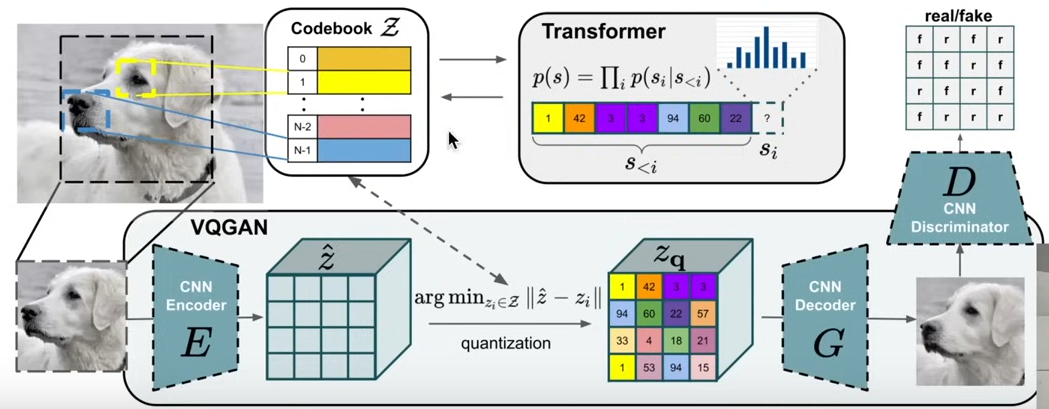

[Source paper: Taming Transformers for High-Resolution Image Synthesis #VQGAN](https://compvis.github.io/taming-transformers/)

### Example 2: SORA

[Source site: Video generation models as world simulations #SORA](https://openai.com/index/video-generation-models-as-world-simulators/)

In [ ]:
# Chunk videos into basically tokens with its own vocabularies.
# Process discrete tokens (e.g. auto regressive models)
# or soft tokens with diffusion models.

# Sentencepiece

[Sentencepiece git](https://github.com/google/sentencepiece)

- Commonly used because (unlike tiktoken) it can efficiently both train and inference BPE tokenizers. It is used in both Llama and Mistral series.  
- The big difference: sentencepiece runs BPE on the Unicode code points directly! It then has an option character_coverage for what to do with very very rare codepoints that appear very few times, and it either maps them onto an UNK token, or if byte_fallback is turned on, it encodes them with utf-8 and then encodes the raw bytes instead.

TLDR:
- tiktoken encodes to utf-8 and then BPEs bytes.
- sentencepiece BPEs the code points and optionally falls back to utf-8 bytes for rare code points (rarity is determined by character_coverage hyperparameter), which then get translated to byte tokens.

(Personally I think the tiktoken way is a lot cleaner...)


-Andrej

In [ ]:
import sentencepiece as spm

In [ ]:
# write a toy.txt file with some random text
with open("toy.txt", "w", encoding="utf-8") as f:
  f.write("SentencePiece is an unsupervised text tokenizer and detokenizer mainly for Neural Network-based text generation systems where the vocabulary size is predetermined prior to the neural model training. SentencePiece implements subword units (e.g., byte-pair-encoding (BPE) [Sennrich et al.]) and unigram language model [Kudo.]) with the extension of direct training from raw sentences. SentencePiece allows us to make a purely end-to-end system that does not depend on language-specific pre/postprocessing.")

Docs for sentencepiece options:

- [markdown](https://github.com/google/sentencepiece/blob/master/doc/options.md)
- [protobuf](https://github.com/google/sentencepiece/blob/master/src/sentencepiece_model.proto#L193)

In [ ]:
# train a sentencepiece model on it
# the settings here are (best effort) those used for training Llama 2
import os

options = dict(
  # input spec
  input="toy.txt",
  input_format="text",
  # output spec
  model_prefix="tok400", # Output filename prefix # Vocab size 400 on that text
  # algorithm spec
  # BPE alg
  model_type="bpe",
  vocab_size=400,
  # normalization
  normalization_rule_name="identity", # ew, turn off normalization
  remove_extra_whitespaces=False,
  input_sentence_size=200000000, # max number of training sentences
  max_sentence_length=4192, # max number of bytes per sentence
  seed_sentencepiece_size=1000000,
  shuffle_input_sentence=True,
  # rare word treatment
  character_coverage=0.99995, # Threshold for if token will be added to vocab
  byte_fallback=True,
  # merge rules
  split_digits=True, # Tiktoken's equivalent of regex
  split_by_unicode_script=True,
  split_by_whitespace=True,
  split_by_number=True,
  max_sentencepiece_length=16,
  add_dummy_prefix=True,
  allow_whitespace_only_pieces=True,
  # special tokens
  unk_id=0, # UNK token MUST exist # Unknown # Beginning of sentence
  bos_id=1, # Others are optional, set to -1 to turn off
  eos_id=2, # End of sentence
  pad_id=-1,# Pad token # -1 means not used
  # systems
  num_threads=os.cpu_count(), # use ~all system resources
)

spm.SentencePieceTrainer.train(**options)

In [ ]:
# Normalization used to be very prevalent in NLP

# In LM/DL, Andrej prefer not to do any of that,
# Keep the raw data in raw form.

In [ ]:
sp = spm.SentencePieceProcessor()
sp.load('tok400.model')
vocab = [[sp.id_to_piece(idx), idx] for idx in range(sp.get_piece_size())]
vocab
# Code points:
# Starts with Special tokens
# Then Byte tokens
# Then Merge tokens (Parents, no children seen)
# Then Indivicual code tokens

# All these raw codepoints to tokens are the ones encountered in the training set
# Note!!!
#   Extremely rare as determined by
#   character_coverage
#   will be ignored and not added to vocab.

[['<unk>', 0],
 ['<s>', 1],
 ['</s>', 2],
 ['<0x00>', 3],
 ['<0x01>', 4],
 ['<0x02>', 5],
 ['<0x03>', 6],
 ['<0x04>', 7],
 ['<0x05>', 8],
 ['<0x06>', 9],
 ['<0x07>', 10],
 ['<0x08>', 11],
 ['<0x09>', 12],
 ['<0x0A>', 13],
 ['<0x0B>', 14],
 ['<0x0C>', 15],
 ['<0x0D>', 16],
 ['<0x0E>', 17],
 ['<0x0F>', 18],
 ['<0x10>', 19],
 ['<0x11>', 20],
 ['<0x12>', 21],
 ['<0x13>', 22],
 ['<0x14>', 23],
 ['<0x15>', 24],
 ['<0x16>', 25],
 ['<0x17>', 26],
 ['<0x18>', 27],
 ['<0x19>', 28],
 ['<0x1A>', 29],
 ['<0x1B>', 30],
 ['<0x1C>', 31],
 ['<0x1D>', 32],
 ['<0x1E>', 33],
 ['<0x1F>', 34],
 ['<0x20>', 35],
 ['<0x21>', 36],
 ['<0x22>', 37],
 ['<0x23>', 38],
 ['<0x24>', 39],
 ['<0x25>', 40],
 ['<0x26>', 41],
 ['<0x27>', 42],
 ['<0x28>', 43],
 ['<0x29>', 44],
 ['<0x2A>', 45],
 ['<0x2B>', 46],
 ['<0x2C>', 47],
 ['<0x2D>', 48],
 ['<0x2E>', 49],
 ['<0x2F>', 50],
 ['<0x30>', 51],
 ['<0x31>', 52],
 ['<0x32>', 53],
 ['<0x33>', 54],
 ['<0x34>', 55],
 ['<0x35>', 56],
 ['<0x36>', 57],
 ['<0x37>', 58],
 ['<0x38>', 5

### Unknown tokens encoding

In [ ]:
ids = sp.encode("hello 안녕하세요")
print(ids)

[362, 378, 361, 372, 358, 362, 239, 152, 139, 238, 136, 152, 240, 152, 155, 239, 135, 187, 239, 157, 151]


In [ ]:
# Note:
# Because byte_fallback=True,
# 안녕하세요 get encoded with utf-8
# Then used one of the ['<0x87>', 138] to represent those bytes

What to do when a bunch of unknown gets mapped into `unk`?
`byte_fallback=True`

In [ ]:
print([sp.id_to_piece(idx) for idx in ids])

['▁', 'h', 'e', 'l', 'lo', '▁', '<0xEC>', '<0x95>', '<0x88>', '<0xEB>', '<0x85>', '<0x95>', '<0xED>', '<0x95>', '<0x98>', '<0xEC>', '<0x84>', '<0xB8>', '<0xEC>', '<0x9A>', '<0x94>']


#### Notice extra space '_' from `add_dummy_prefix=True`

makes "world" and " world" as the same token.

## Llama Tokenizer

**Llama 2 tokenizer proto**
If you'd like to export the raw protocol buffer for the `tokenizer.model` released by meta, this is a [helpful issue](https://github.com/google/sentencepiece/issues/121). And this is the result:

```
normalizer_spec {
  name: "identity"
  precompiled_charsmap: ""
  add_dummy_prefix: true
  remove_extra_whitespaces: false
  normalization_rule_tsv: ""
}

trainer_spec {
  input: "/large_experiments/theorem/datasets/MERGED/all.test1.merged"
  model_prefix: "spm_model_32k_200M_charcov099995_allowWSO__v2"
  model_type: BPE
  vocab_size: 32000
  self_test_sample_size: 0
  input_format: "text"
  character_coverage: 0.99995
  input_sentence_size: 200000000
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  num_threads: 80
  num_sub_iterations: 2
  max_sentence_length: 4192
  shuffle_input_sentence: true
  max_sentencepiece_length: 16
  split_by_unicode_script: true
  split_by_whitespace: true
  split_by_number: true
  treat_whitespace_as_suffix: false
  split_digits: true
  allow_whitespace_only_pieces: true
  vocabulary_output_piece_score: true
  hard_vocab_limit: true
  use_all_vocab: false
  byte_fallback: true
  required_chars: ""
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_surface: " \342\201\207 "
  unk_piece: "<unk>"
  bos_piece: "<s>"
  eos_piece: "</s>"
  pad_piece: "<pad>"
  train_extremely_large_corpus: false
  enable_differential_privacy: false
  differential_privacy_noise_level: 0.0
  differential_privacy_clipping_threshold: 0
}
```

# Final recommendations

> - Don't brush off tokenization. A lot of footguns and sharp edges here. Security issues. Safety issues (Unalloc).
- Eternal glory to anyone who can delete tokenization as a required step in LLMs. [This paper, MEGABYTE: Predicting Million-byte Sequences with Multiscale  Transformers](https://arxiv.org/abs/2305.07185)
- In your own application:
  - Maybe you can just re-use the GPT-4 tokens and tiktoken?
  - If you're training a vocab, ok to use BPE with sentencepiece. Careful with the million settings.
  - Switch to minbpe once it is as efficient as sentencepiece :)


Andrej's issues with sentencepiece
- `byte_fallback`
- BPE unicode codepoints
- Too much settings
